# Data Tranformation(DGS_Reduction)

# Load data as Scipp DataArray (McStasToX)

In [1]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

data_path = (
    parent
    + "/runs/TREX_Cold_Sample_Vana_SingleEi_MultiEi/3p58meV/TREX_3p58meV_HR_Sample_FullBand_20260710_103753"
)

with mx.Read(data_path) as mcstas_data:
    scipp_data_group = mcstas_data.export_scipp(
        source_name="ESS_source",
        sample_name="Sample",
    )
display(scipp_data_group)
det_positions = scipp_data_group["positions"]

DataGroup(sizes={'pixel_id': 39168, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 39168}),
    positions: Variable({'pixel_id': 39168}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

The events are binned by pixel_id, only pixels with events recored are saved in data. This allows for masking by pixel_id 

In [2]:
events_binned = scipp_data_group["events"]
display(events_binned)
sample_position = events_binned.coords["sample_position"]

# mask back scattering pixels
mask = events_binned.coords["position"].fields.z > sample_position.fields.z
# events_binned = events_binned[mask]

<scipp.DataArray>
Dimensions: Sizes[pixel_id:39168, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 39166, 39167]
* position                  vector3              [m]  (pixel_id)  [(-0.901516, -1.38991, 166.265), (-0.874691, -1.38991, 166.283), ..., (2.61501, 0.793912, 161.404), (2.5886, 0.793912, 161.384)]
* sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 617849),
          data=float64[counts],
          coords={'t':float64[s]})

In [3]:
frac_forward = sc.sum(mask).value / len(mask)
frac_forward

np.float64(0.6979166666666666)

# Read in Monitor data (McStasScript/McStasToX)

In [4]:
import mcstasscript as ms
from reduction.dgs_reduction import monitor_multi_pulse

mcstas_data = ms.load_data(data_path)
presample_monitor_data = ms.name_search("sample_monitor_ToF_cm2", mcstas_data)
monitor_data = monitor_multi_pulse(
    presample_monitor_data, rrm=8, threshold_fraction=0.02, unit="s"
)

  Expected ~8 frames (RRM=8)
  Detected 9 peaks
  Min distance used: 1 bins (0.0 s)
    Peak  0: t=0.17 s  counts=1.268e+04
    Peak  1: t=0.18 s  counts=3.943e+04
    Peak  2: t=0.19 s  counts=3.285e+04
    Peak  3: t=0.19 s  counts=3.062e+04
    Peak  4: t=0.20 s  counts=2.757e+04
    Peak  5: t=0.21 s  counts=2.516e+04
    Peak  6: t=0.21 s  counts=2.326e+04
    Peak  7: t=0.22 s  counts=2.062e+04
    Peak  8: t=0.23 s  counts=8.647e+03


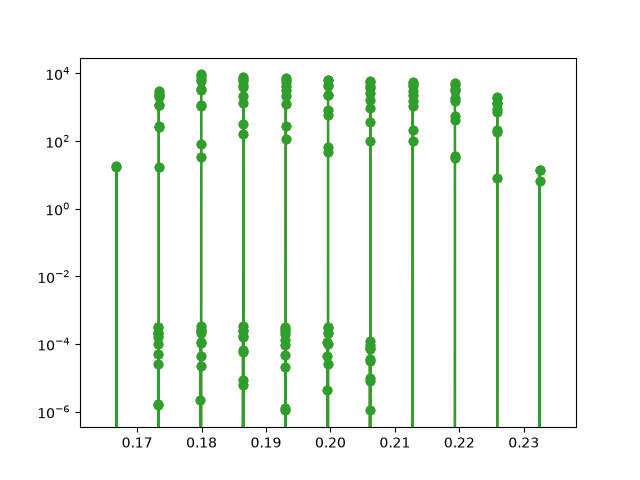

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

intensity = np.asarray(
    presample_monitor_data.Intensity, dtype=float
)  # intensity in monitor
xaxis = np.asarray(presample_monitor_data.xaxis, dtype=float)
plt.semilogy(xaxis, intensity, "-o")
plt.show()

In [6]:
with mx.Read(data_path) as mcstas_data:
    presample_monitor_position = mcstas_data.get_global_component_coordinates(
        component_name="sample_monitor_ToF_cm2"
    )

monitor_data.coords["presample_monitor_position"] = sc.vector(
    value=presample_monitor_position, unit="m"
)
monitor_data.coords["source_position"] = events_binned.coords.pop("source_position")
monitor_data.coords["sample_position"] = events_binned.coords.pop("sample_position")

# Calculate Ei per RRM

<scipp.DataArray>
Dimensions: Sizes[rrm:9, ]
Coordinates:
* ei                        float64            [meV]  (rrm)  [4.75982, 4.41552, ..., 2.96158, 2.79062]
* ki                        vector3           [1/Å]  (rrm)  [(0.00768086, 0, 1.51559), (0.00739786, 0, 1.45975), ..., (0.00605866, 0, 1.1955), (0.00588119, 0, 1.16048)]
  presample_monitor_position  vector3              [m]  ()  (0.830123, 0, 163.8)
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
  source_position           vector3              [m]  ()  (0, 0, 0)
  time_on_monitor           float64              [s]  (rrm)  [0.173353, 0.17992, ..., 0.219314, 0.22588]
* time_on_sample            float64              [s]  (rrm)  [0.173369, 0.179936, ..., 0.219333, 0.225901]
  time_on_source            float64              [s]  ()  0.0017
Data:
                            float64         [counts]  (rrm)  [12680.3, 39426.2, ..., 20617.7, 8647.22]

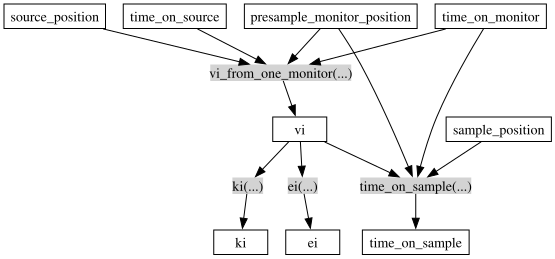

In [7]:
from dgs_reduction import calculate_ei

monitor_data.coords["time_on_source"] = sc.scalar(value=1.7, unit="ms").to(unit="s")

monitor_data = monitor_data.transform_coords(
    ["ki", "ei", "time_on_sample"],
    graph=calculate_ei,
    keep_intermediate=False,
)
display(monitor_data)
sc.show_graph(calculate_ei)

# Calculate the INS time windows (per pixel, per RRM)
By defualt, keep events where energy transfer E = Ei - Ef is within ±0.8*Ei. Events outside this range will be masked later. Notice that sample to detector distance varys, so the TOA windows are different per pxiel_id, per RRM.

In [8]:
from dgs_reduction import determine_INS_windows

norm_factors = determine_INS_windows(
    monitor_data, det_positions, energy_transfer_ratio=(-0.8, 0.8)
)
display(norm_factors)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:39168, rrm:9, ]
Coordinates:
* detector_positions        vector3              [m]  (pixel_id)  [(-0.901516, -1.38991, 166.265), (-0.874691, -1.38991, 166.283), ..., (2.61501, 0.793912, 161.404), (2.5886, 0.793912, 161.384)]
* ei                        float64            [meV]  (rrm)  [4.75982, 4.41552, ..., 2.96158, 2.79062]
* ki                        vector3           [1/Å]  (rrm)  [(0.00768086, 0, 1.51559), (0.00739786, 0, 1.45975), ..., (0.00605866, 0, 1.1955), (0.00588119, 0, 1.16048)]
* monitor_counts            float64         [counts]  (rrm)  [12680.3, 39426.2, ..., 20617.7, 8647.22]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* time_on_sample            float64              [s]  (rrm)  [0.173369, 0.179936, ..., 0.219333, 0.225901]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.181117, 0.18798, ..., 0.228552, 0.235398]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.175952, 0.182618, ..., 0.222406, 0.229066]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Flatten the binned events, add pixel_id as coordinate

In [9]:
events_binned.bins.coords["pixel_id"] = sc.bins_like(
    events_binned.data, events_binned.coords["pixel_id"]
)
events = events_binned.bins.concat().value.copy()
events.coords["toa"] = events.coords.pop("t")
display(events)

<scipp.DataArray>
Dimensions: Sizes[events:617849, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 39167, 39167]
* toa                       float64              [s]  (events)  [0.196919, 0.203635, ..., 0.183358, 0.196487]
Data:
                            float64         [counts]  (events)  [0.0259868, 0.0371552, ..., 0.0250047, 6.44108e-10]

# Assgin RRM index of TOA based on toa_min mask data between toa_max and toa_min

In [10]:
from dgs_reduction import assign_rrm

events = assign_rrm(events, norm_factors)
events

<scipp.DataArray>
Dimensions: Sizes[events:617849, ]
Coordinates:
* detector_positions        vector3              [m]  (events)  [(-0.901516, -1.38991, 166.265), (-0.901516, -1.38991, 166.265), ..., (2.5886, 0.793912, 161.384), (2.5886, 0.793912, 161.384)]
* ei                        float64            [meV]  (events)  [3.83031, 3.58039, ..., 4.41552, 3.83031]
* ki                        vector3           [1/Å]  (events)  [(0.0068902, 0, 1.35958), (0.00666163, 0, 1.31447), ..., (0.00739786, 0, 1.45975), (0.0068902, 0, 1.35958)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 39167, 39167]
* rrm                         int64  [dimensionless]  (events)  [3, 4, ..., 1, 3]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* time_on_sample            float64              [s]  (events)  [0.193068, 0.199635, ..., 0.179936, 0.193068]
* toa                       float64              [s]  (events)  [0.196919, 0.203635, ..., 0.183358, 0.196487]
Data:
                            float64         [counts]  (events)  [0.0259868, 0.0371552, ..., 0.0250047, 6.44108e-10]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

# Convert from (pixel_id, toa) to (Q, E)

<scipp.DataArray>
Dimensions: Sizes[events:617849, ]
Coordinates:
  detector_positions        vector3              [m]  (events)  [(-0.901516, -1.38991, 166.265), (-0.901516, -1.38991, 166.265), ..., (2.5886, 0.793912, 161.384), (2.5886, 0.793912, 161.384)]
  ef                        float64            [meV]  (events)  [3.85422, 3.57002, ..., 4.29969, 4.30797]
  ei                        float64            [meV]  (events)  [3.83031, 3.58039, ..., 4.41552, 3.83031]
* en                        float64            [meV]  (events)  [-0.0239141, 0.0103727, ..., 0.115837, -0.477659]
* kf                        vector3           [1/Å]  (events)  [(-0.71433, -0.573325, 1.01048), (-0.687489, -0.551782, 0.972509), ..., (0.816208, 0.368522, -1.12828), (0.816993, 0.368876, -1.12936)]
  ki                        vector3           [1/Å]  (events)  [(0.0068902, 0, 1.35958), (0.00666163, 0, 1.31447), ..., (0.00739786, 0, 1.45975), (0.0068902, 0, 1.35958)]
* pixel_id                    int64  [dimensionless]  (events)  [0, 0, ..., 39167, 39167]
  q                         vector3           [1/Å]  (events)  [(0.72122, 0.573325, 0.349098), (0.694151, 0.551782, 0.341964), ..., (-0.80881, -0.368522, 2.58802), (-0.810103, -0.368876, 2.48894)]
* q_mag                     float64           [1/Å]  (events)  [0.985256, 0.950394, ..., 2.73639, 2.64332]
* qx                        float64           [1/Å]  (events)  [0.72122, 0.694151, ..., -0.80881, -0.810103]
* qy                        float64           [1/Å]  (events)  [0.573325, 0.551782, ..., -0.368522, -0.368876]
* qz                        float64           [1/Å]  (events)  [0.349098, 0.341964, ..., 2.58802, 2.48894]
* rrm                         int64  [dimensionless]  (events)  [3, 4, ..., 1, 3]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
  time_on_sample            float64              [s]  (events)  [0.193068, 0.199635, ..., 0.179936, 0.193068]
  toa                       float64              [s]  (events)  [0.196919, 0.203635, ..., 0.183358, 0.196487]
  vf                        vector3            [m/s]  (events)  [(-449.758, -360.978, 636.219), (-432.859, -347.414, 612.314), ..., (513.903, 232.029, -710.389), (514.397, 232.253, -711.072)]
Data:
                            float64         [counts]  (events)  [0.0259868, 0.0371552, ..., 0.0250047, 6.44108e-10]
Masks:
  outside                      bool        <no unit>  (events)  [False, False, ..., False, False]

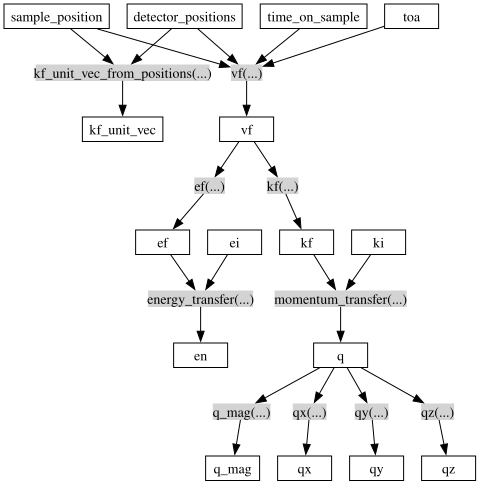

In [11]:
from dgs_reduction import calculate_qe

events = events.transform_coords(
    ["qx", "qy", "qz", "en", "q_mag", "kf"],
    graph=calculate_qe,
    keep_intermediate=True,
)
display(events)
sc.show_graph(calculate_qe)

# Plot events to check for coverage
Notice here we do not ditinguish diffferent RRMs, all events are used for histogramming

In [12]:
%matplotlib widget
import plopp as pp
from dgs_reduction import generate_bins, generate_plot_coords_and_title

grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (-0.2, 0.2),
}

bins = generate_bins(grid)
display(bins)

plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)

{'qx': <scipp.Variable> (qx: 36)    float64           [1/Å]  [-2, -1.9, ..., 1.4, 1.5],
 'qy': <scipp.Variable> (qy: 41)    float64           [1/Å]  [-2, -1.9, ..., 1.9, 2],
 'qz': <scipp.Variable> (qz: 2)    float64           [1/Å]  [-1, 1],
 'en': <scipp.Variable> (en: 2)    float64            [meV]  [-0.2, 0.2]}

<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:40, qz:1, en:1, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-0.2, 0.2]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-2, -1.9, ..., 1.9, 2]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-1, 1]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

In [13]:
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    title=plot_title,
    vmin=0,
    vmax=1e2,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [14]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5),
    "en": (-1, 1, 0.01),
}

bins = generate_bins(grid)
plot_coords, plot_title = generate_plot_coords_and_title(bins)

data_hist = sc.bin(events, **bins).hist()
display(data_hist)

<scipp.DataArray>
Dimensions: Sizes[qx:35, qy:1, qz:1, en:200, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-1, -0.99, ..., 0.99, 1]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-2, -1.9, ..., 1.4, 1.5]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
Data:
                            float64         [counts]  (qx, qy, qz, en)  [0, 0, ..., 0, 0]

In [15]:
pp.plot(
    data_hist.squeeze().transpose(),
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=40,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Calculate normalization factors for histogramming (MDNorm)

# Calculate detector solid angles from a white beam Vanadium run (counts per pixel)

In [16]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

parent = os.path.dirname(os.getcwd())
van_path = (
    parent
    + "/runs/TREX_Cold_Sample_Vana_SingleEi_MultiEi/3p58meV/TREX_3p58meV_HR_Vana_FullBand_20260710_103754"
)

with mx.Read(van_path) as mcstas_van_data:
    scipp_van_data_group = mcstas_van_data.export_scipp(
        source_name="ESS_source",
        sample_name="Sample",
    )

v_events_binned = scipp_van_data_group["events"]
display(v_events_binned)
# Group by pixel_id to fill in the pixels that recorded no events
detector_posisitions = scipp_van_data_group["positions"]
sample_position = v_events_binned.coords["sample_position"]
v_events = v_events_binned.group(
    sc.arange(detector_posisitions.dim, 0, detector_posisitions.size)
)
display(v_events)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:39168, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 39166, 39167]
* position                  vector3              [m]  (pixel_id)  [(-0.901516, -1.38991, 166.265), (-0.874691, -1.38991, 166.283), ..., (2.61501, 0.793912, 161.404), (2.5886, 0.793912, 161.384)]
* sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 620839),
          data=float64[counts],
          coords={'t':float64[s]})

<scipp.DataArray>
Dimensions: Sizes[pixel_id:39168, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 39166, 39167]
* sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 620839),
          data=float64[counts],
          coords={'t':float64[s]})

# Mask the leakage from beamstop

In [17]:
import numpy as np

d_omega_exp = v_events.hist().data
# mask = d_omega_exp > sc.scalar(0.0015, unit=d_omega_exp.unit)
# d_omega_exp = sc.where(mask, sc.scalar(np.nan, unit=d_omega_exp.unit), d_omega_exp)

d_omega_exp /= d_omega_exp.nansum()
print(d_omega_exp)
# norm_factors.coords["d_omega_exp"] = d_omega

<scipp.Variable> (pixel_id: 39168)    float64  [dimensionless]  [1.30425e-05, 1.39495e-05, ..., 2.79824e-05, 2.75164e-05]


# Visualize the Vanadium data

In [18]:
import plopp as pp

theta_bins = 288
theta_limits = [-36, 144]
y_bins = 136
yheight = 2.2

nx, ny = theta_bins, y_bins
v_cylinder = sc.DataArray(
    data=sc.Variable(
        dims=["height", "two_theta"], values=np.reshape(d_omega_exp.values, (ny, nx))
    ),
    coords={
        "two_theta": sc.linspace(
            dim="two_theta", start=theta_limits[0], stop=theta_limits[1], num=nx
        ),
        "height": sc.linspace(
            dim="height", start=-yheight / 2, stop=yheight / 2, num=ny
        ),
    },
)

pp.plot(
    v_cylinder, title="Vanadium cylinder", vmin=0, vmax=1e-4, cmap="turbo", grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

<scipp.DataArray>
Dimensions: Sizes[pixel_id:39168, ]
Coordinates:
  detector_geometry          string        <no unit>  ()  "cylinder"
  pixel_height              float64              [m]  ()  0.0161765
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 39166, 39167]
  pixel_position            vector3              [m]  (pixel_id)  [(-1.73175, -1.38991, 2.4497), (-1.70493, -1.38991, 2.46845), ..., (1.78478, 0.793912, -2.41134), (1.75837, 0.793912, -2.43067)]
* pixel_solid_angle         float64             [sr]  (pixel_id)  [4.39375e-05, 4.39375e-05, ..., 5.31392e-05, 5.31392e-05]
  pixel_width               float64              [m]  ()  0.0327248
* sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 620839),
          data=float64[counts],
          coords={'t':float64[s]})

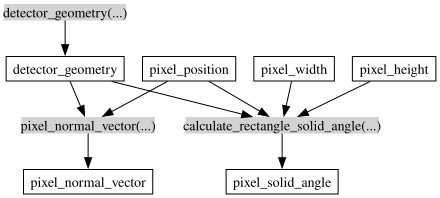

In [19]:
from reduction.dgs_reduction import calculate_solid_angle

h = sc.norm(detector_posisitions[theta_bins] - detector_posisitions[0])
w = sc.norm(detector_posisitions[1] - detector_posisitions[0])
r = detector_posisitions - sample_position

v_events.coords["pixel_position"] = r
v_events.coords["pixel_height"] = h
v_events.coords["pixel_width"] = w
v_events = v_events.transform_coords(
    [
        "pixel_solid_angle",
    ],
    graph=calculate_solid_angle,
)
display(v_events)
sc.show_graph(calculate_solid_angle)

In [20]:
pp.plot(
    {
        "McStas": d_omega_exp,
        "Calc": v_events.coords["pixel_solid_angle"]
        / sc.sum(v_events.coords["pixel_solid_angle"]),
    },
    ylabel="fractional counts",
    title="Vanadium counts/pixel over total counts",
    linestyle="-",
    markersize=2,
    # ymax=2e-5,
    ymin=0.0,
    grid=True,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [21]:
norm_factors.coords["d_omega"] = v_events.coords["pixel_solid_angle"]
norm_factors

<scipp.DataArray>
Dimensions: Sizes[pixel_id:39168, rrm:9, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [4.39375e-05, 4.39375e-05, ..., 5.31392e-05, 5.31392e-05]
* detector_positions        vector3              [m]  (pixel_id)  [(-0.901516, -1.38991, 166.265), (-0.874691, -1.38991, 166.283), ..., (2.61501, 0.793912, 161.404), (2.5886, 0.793912, 161.384)]
* ei                        float64            [meV]  (rrm)  [4.75982, 4.41552, ..., 2.96158, 2.79062]
* ki                        vector3           [1/Å]  (rrm)  [(0.00768086, 0, 1.51559), (0.00739786, 0, 1.45975), ..., (0.00605866, 0, 1.1955), (0.00588119, 0, 1.16048)]
* monitor_counts            float64         [counts]  (rrm)  [12680.3, 39426.2, ..., 20617.7, 8647.22]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
* time_on_sample            float64              [s]  (rrm)  [0.173369, 0.179936, ..., 0.219333, 0.225901]
* toa_max                   float64              [s]  (pixel_id, rrm)  [0.181117, 0.18798, ..., 0.228552, 0.235398]
* toa_min                   float64              [s]  (pixel_id, rrm)  [0.175952, 0.182618, ..., 0.222406, 0.229066]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

# Calculate detector trajectory endpoints (per pixel, per RRM)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:39168, rrm:9, ]
Coordinates:
* d_omega                   float64             [sr]  (pixel_id)  [4.39375e-05, 4.39375e-05, ..., 5.31392e-05, 5.31392e-05]
  detector_positions        vector3              [m]  (pixel_id)  [(-0.901516, -1.38991, 166.265), (-0.874691, -1.38991, 166.283), ..., (2.61501, 0.793912, 161.404), (2.5886, 0.793912, 161.384)]
  ef_gain                   float64            [meV]  (pixel_id, rrm)  [8.56767, 7.94794, ..., 5.33084, 5.02311]
  ef_loss                   float64            [meV]  (pixel_id, rrm)  [0.951964, 0.883105, ..., 0.592315, 0.558123]
  ei                        float64            [meV]  (rrm)  [4.75982, 4.41552, ..., 2.96158, 2.79062]
* energy_gain_ratio         float64  [dimensionless]  (pixel_id, rrm)  [-0.8, -0.8, ..., -0.8, -0.8]
* energy_loss_ratio         float64  [dimensionless]  (pixel_id, rrm)  [0.8, 0.8, ..., 0.8, 0.8]
* kf_M                      vector3           [1/Å]  (pixel_id, rrm)  [(-1.06503, -0.854798, 1.50657), (-1.02579, -0.823303, 1.45106), ..., (0.908825, 0.410338, -1.25631), (0.882203, 0.398319, -1.21951)]
  kf_M_mag                  float64           [1/Å]  (pixel_id, rrm)  [2.0334, 1.95848, ..., 1.60395, 1.55696]
* kf_m                      vector3           [1/Å]  (pixel_id, rrm)  [(-0.35501, -0.284933, 0.50219), (-0.34193, -0.274434, 0.483687), ..., (0.302942, 0.136779, -0.418768), (0.294068, 0.132773, -0.406502)]
  kf_m_mag                  float64           [1/Å]  (pixel_id, rrm)  [0.677801, 0.652827, ..., 0.534649, 0.518988]
  kf_unit_vec               vector3  [dimensionless]  (pixel_id)  [(-0.523767, -0.420378, 0.740911), (-0.515654, -0.420378, 0.746581), ..., (0.575128, 0.255831, -0.777032), (0.566618, 0.255831, -0.783259)]
  ki                        vector3           [1/Å]  (rrm)  [(0.00768086, 0, 1.51559), (0.00739786, 0, 1.45975), ..., (0.00605866, 0, 1.1955), (0.00588119, 0, 1.16048)]
* monitor_counts            float64         [counts]  (rrm)  [12680.3, 39426.2, ..., 20617.7, 8647.22]
* q_M                       vector3           [1/Å]  (pixel_id, rrm)  [(1.07271, 0.854798, 0.00901818), (1.03319, 0.823303, 0.0086859), ..., (-0.902766, -0.410338, 2.4518), (-0.876322, -0.398319, 2.37998)]
* q_m                       vector3           [1/Å]  (pixel_id, rrm)  [(0.362691, 0.284933, 1.0134), (0.349327, 0.274434, 0.97606), ..., (-0.296883, -0.136779, 1.61426), (-0.288187, -0.132773, 1.56698)]
  sample_position           vector3              [m]  ()  (0.830235, 0, 163.815)
  time_on_sample            float64              [s]  (rrm)  [0.173369, 0.179936, ..., 0.219333, 0.225901]
  toa_max                   float64              [s]  (pixel_id, rrm)  [0.181117, 0.18798, ..., 0.228552, 0.235398]
  toa_min                   float64              [s]  (pixel_id, rrm)  [0.175952, 0.182618, ..., 0.222406, 0.229066]
Data:
                            float64  [dimensionless]  (pixel_id, rrm)  [0, 0, ..., 0, 0]

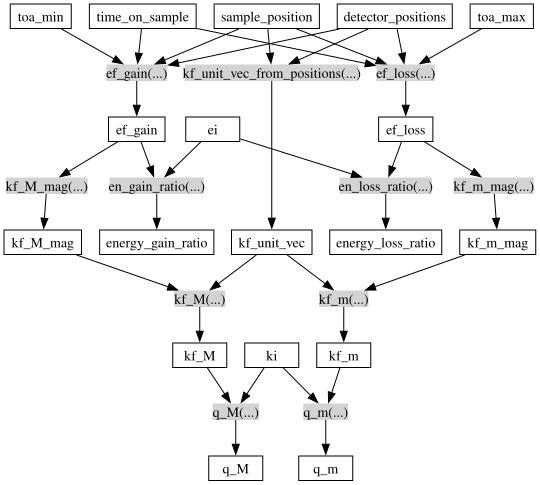

In [22]:
from dgs_reduction import calculate_trajectory_endpoints

norm_factors = norm_factors.transform_coords(
    [
        "energy_gain_ratio",
        "energy_loss_ratio",
        "kf_m",
        "kf_M",
        "q_m",
        "q_M",
    ],
    graph=calculate_trajectory_endpoints,
)
display(norm_factors)
sc.show_graph(calculate_trajectory_endpoints)

In [23]:
from dgs_reduction import mdnorm

grid = {
    "qx": (-3, 3, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (-0.2, 0.2),
}

rrm = 0
data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [24]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=1e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [25]:
grid = {
    "qx": (-3, 3, 0.1),
    "qy": (-2, 2, 0.1),
    "qz": (-1.0, 1.0),
    "en": (2.0, 2.2),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [26]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=1e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [27]:
grid = {
    "qx": (-3, 1.5, 0.1),
    "qy": (-0.02, 0.02),
    "qz": (-1, 3.0, 0.2),
    "en": (-0.2, 0.2),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [28]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [29]:
grid = {
    "qx": (-2, 1.5, 0.1),
    "qy": (-0.1, 0.1),
    "qz": (-1, 3.0, 0.1),
    "en": (2.0, 2.2),
}

data, plot_coords, plot_title = mdnorm(
    events,
    grid,
    norm_factors,
    rrm=rrm,
)

In [30]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# averaging over a large Q ranges is very slow

In [31]:
grid = {
    "qx": (-1.5, 1.0),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 3.5, 0.1),
    "en": (-4, 4, 0.02),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [32]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Plot a 1D cut

In [33]:
grid = {
    "qx": (-1.5, 1.0),
    "qy": (-1.0, 1.0),
    "qz": (-0.5, 2.5),
    "en": (-4, 4, 0.02),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [34]:
data

<scipp.DataArray>
Dimensions: Sizes[en:400, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.98, ..., 3.98, 4]
  qx                        float64           [1/Å]  (qx [bin-edge])  [-1.5, 1]
  qy                        float64           [1/Å]  (qy [bin-edge])  [-1, 1]
  qz                        float64           [1/Å]  (qz [bin-edge])  [-0.5, 2.5]
Data:
                            float64       [1/sr/meV]  (en)  [nan, nan, ..., inf, inf]

In [35]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=3e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [36]:
grid = {
    "qx": (-1.5, 1.0, 0.05),
    "qy": (-1.0, 1.0),
    "qz": (-0.0, 1.0),
    "en": (-0.5, 0.5, 0.005),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [37]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Plot |Q| vs. E for powder samples

In [38]:
grid = {
    "qx": (-3, 3.0, 0.1),
    "qy": (-3.0, 3.0, 0.1),
    "qz": (-3, 3, 0.1),
    "en": (-4, 4, 0.005),
}

data4d, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

mag_q = sc.sqrt(
    sc.midpoints(data4d.coords["qx"]) ** 2
    + sc.midpoints(data4d.coords["qy"]) ** 2
    + sc.midpoints(data4d.coords["qz"]) ** 2
)

data4d.coords["mag_q"] = mag_q
data4d

<scipp.DataArray>
Dimensions: Sizes[en:1600, qz:60, qy:60, qx:60, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.995, ..., 3.995, 4]
* mag_q                     float64           [1/Å]  (qx, qy, qz)  [5.10955, 5.05247, ..., 5.05247, 5.10955]
* qx                        float64           [1/Å]  (qx [bin-edge])  [-3, -2.9, ..., 2.9, 3]
* qy                        float64           [1/Å]  (qy [bin-edge])  [-3, -2.9, ..., 2.9, 3]
* qz                        float64           [1/Å]  (qz [bin-edge])  [-3, -2.9, ..., 2.9, 3]
Data:
                            float64       [1/sr/meV]  (en, qz, qy, qx)  [nan, nan, ..., nan, nan]

In [39]:
q_bins = sc.linspace("mag_q", 0.0, 4.0, num=100, unit="1/Å")
rebinned = data4d.bin(mag_q=q_bins)
data_rebinned = rebinned.bins.nanmean()
display(data_rebinned)

<scipp.DataArray>
Dimensions: Sizes[en:1600, mag_q:99, ]
Coordinates:
* en                        float64            [meV]  (en [bin-edge])  [-4, -3.995, ..., 3.995, 4]
* mag_q                     float64           [1/Å]  (mag_q [bin-edge])  [0, 0.040404, ..., 3.9596, 4]
Data:
                            float64       [1/sr/meV]  (en, mag_q)  [nan, nan, ..., nan, nan]

In [40]:
pp.plot(
    data_rebinned,
    grid=True,
    cmap="turbo",
    vmin=1e-11,
    vmax=5e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [41]:
grid = {
    "qx": (-3.0, 2.0),
    "qy": (-3.0, 2.0),
    "qz": (-3.0, 2.0),
    "en": (-4, 4, 0.005),
}

data, plot_coords, plot_title = mdnorm(events, grid, norm_factors, rrm=rrm)

In [42]:
pp.plot(
    data,
    coords=plot_coords,
    grid=True,
    cmap="turbo",
    vmin=1e-11,
    vmax=3e-1,
    title=plot_title,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…